# Ovarian cancer data analysis
Train steamboat model on HGSC data.

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import scipy as sp

In [3]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'arial'

pltkw = dict(bbox_inches='tight', transparent=True)

In [4]:
# https://www.nature.com/articles/s41590-024-01943-5

## Load data

In [ ]:
regenerate = False

h5ad_file = "../../data/Ex1_hgsc/ST_Discovery_so.h5ad"
if (not os.path.exists(h5ad_file)) or regenerate:
    adata = sc.read_mtx("../../data/Ex1_hgsc/Csv/ST_Discovery_so_counts.mtx").T
    metadata = pd.read_csv("../../data/Ex1_hgsc/Csv/ST_Discovery_so_metadata.csv", index_col=0)
    features = pd.read_csv("../../data/Ex1_hgsc/Csv/ST_Discovery_so_features.txt", index_col=0, header=None)
    features.index = features.index.str.strip() # remove trailing white space in gene names
    features.index.name = 'gene_symbol'
    adata.obs = metadata
    adata.var = features
    adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()
    adata.write_h5ad(h5ad_file)
else:
    adata = sc.read_h5ad(h5ad_file)

In [ ]:
## Metadata and gene sets

sample_metadata = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", index_col=0, sheet_name='Table 2b', skiprows=1)
sample_metadata = sample_metadata[sample_metadata['dataset'] == 'Discovery']

celltype_signatures = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", sheet_name='Table 3a', skiprows=2)
mtil_signautures = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", sheet_name='Table 6a', skiprows=2)
desmoplasia_signautures = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", sheet_name='Table 5a', skiprows=2)

def purge_gene_sets(df, prefix=''):
    res = {}
    for i in df.columns:
        res[prefix + i] = df[i].dropna().tolist()
    return res
celltype_signatures = pd.read_excel("../../data/Ex1_hgsc/sample_metadata.xlsx", index_col=0, sheet_name='Table 3b', skiprows=2).iloc[:, :-3]
genesets = (purge_gene_sets(celltype_signatures, 'sig_') | 
            purge_gene_sets(mtil_signautures, 'mtil_') | 
            purge_gene_sets(mtil_signautures, 'mtil_'))
genesets.keys()
del genesets['sig_Mast.cell']

sample_metadata

,dataset,platform,n_cells,median_tpc,mean_tpc,TMA,patients,sites_binary,age,stage,...,fu_time2,outcome,pfs,BRCA1_Somatic,BRCA2_Somatic,TP53_Somatic,BRCA1_Germline,BRCA2_Germline,TP53_Germline,tmb
profile,,,,,,,,,,,,,,,,,,,,,
SMI_T10_F001,Discovery,SMI,5660,205.0,238.675618,TMA 10,HGSC1,Adnexa,58.0,III,...,775.0,Alive,775.0,WT,P,P,US,US,US,6.80
SMI_T10_F002,Discovery,SMI,8821,364.0,393.318671,TMA 10,HGSC7,Adnexa,58.0,III,...,1013.0,Alive,1013.0,P,WT,LP,US,US,US,0.53
SMI_T10_F003,Discovery,SMI,2881,300.0,445.154460,TMA 10,HGSC8,Adnexa,65.0,IV,...,781.0,Alive,200.0,WT,WT,P,US,US,US,3.16
SMI_T10_F004,Discovery,SMI,3145,286.0,376.895390,TMA 10,HGSC13,Omentum,67.0,III,...,840.0,Dead (disease),161.0,WT,WT,P,US,US,US,2.63
SMI_T10_F005,Discovery,SMI,2187,165.0,267.202561,TMA 10,HGSC15,Adnexa,33.0,IV,...,845.0,Alive,845.0,WT,WT,P,P,US,US,2.63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SMI_T14_F016,Discovery,SMI,2744,209.0,288.211735,TMA 14,HGSC61,Omentum,70.0,III,...,1955.0,Alive,1955.0,WT,WT,P,US,US,US,1.10
SMI_T14_F017,Discovery,SMI,3376,276.0,368.816647,TMA 14,HGSC63,Omentum,71.0,III,...,407.0,D/c to hospice (likely dead of disease),297.0,WT,WT,P,US,US,US,0.50
SMI_T14_F018,Discovery,SMI,9961,189.0,210.500452,TMA 14,HGSC89,Adnexa,53.0,III,...,1729.0,Dead (disease),412.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


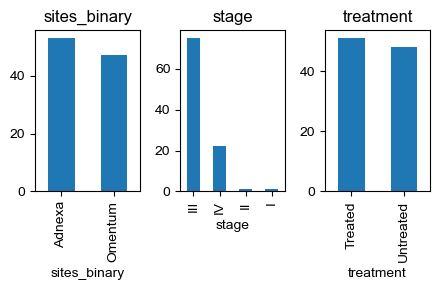

In [7]:
## Find untreated, adnexa samples

columns_of_interest = ['sites_binary', 'stage', 'treatment']
fig, axes = plt.subplots(1, len(columns_of_interest), figsize=(len(columns_of_interest) * 1.5, 3))
for i, column in enumerate(columns_of_interest):
    sample_metadata[column].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()

mask = (sample_metadata['sites_binary'] == 'Adnexa') & (sample_metadata['treatment'] == 'Untreated')
samples_of_interest = sample_metadata.index[mask].tolist()

all_adata = adata[adata.obs['samples'].isin(samples_of_interest)].copy()
all_adata.obs['cell.types.nolc'] = all_adata.obs['cell.types'].str.replace('_LC', '')

In [8]:
# selected_samples = np.random.choice(all_adata.obs['samples'].unique(), size=10, replace=False)
# all_adata = all_adata[all_adata.obs['samples'].isin(selected_samples)].copy()

In [16]:
# Separate individual slides
adatas = []
for i in all_adata.obs['samples'].unique():
    temp = all_adata[all_adata.obs['samples'] == i].copy()
    if temp.shape[0] < 100:
        continue
    adatas.append(temp)
    sc.pp.normalize_total(adatas[-1])
    sc.pp.log1p(adatas[-1])
    sq.gr.spatial_neighbors(adatas[-1])

In [26]:
import numpy as np
import pandas as pd
from anndata import AnnData
from scipy.sparse import coo_matrix
from tqdm.auto import tqdm # For a nice progress bar

def _count_interactions(
    adj_matrix_coo: coo_matrix, 
    cell_labels: np.ndarray, 
    type_map: dict
) -> np.ndarray:
    """
    Internal helper function to count directional interactions.
    
    This replaces the logic from Calculate_STDandMean.m
    """
    n_types = len(type_map)
    counts = np.zeros((n_types, n_types), dtype=np.int32)
    
    # Iterate over all neighbor pairs (edges in the graph)
    # adj_matrix_coo.row[k] is the 'source' cell index
    # adj_matrix_coo.col[k] is the 'neighbor' cell index
    for i_cell, j_neighbor in zip(adj_matrix_coo.row, adj_matrix_coo.col):
        
        # Get the cell types for the source cell and its neighbor
        type_i = cell_labels[i_cell]
        type_j = cell_labels[j_neighbor]
        
        # Get the matrix indices for these types
        idx_i = type_map[type_i]
        idx_j = type_map[type_j]
        
        # Increment the count for this directional interaction (i -> j)
        counts[idx_i, idx_j] += 1
        
    return counts

def neighborhood_enrichment(
    adata: AnnData,
    cluster_key: str,
    connectivity_key: str = 'spatial_connectivities',
    n_permutations: int = 1000
) -> (pd.DataFrame, pd.DataFrame, pd.DataFrame):
    """
    Calculates neighborhood enrichment using the histoCAT permutation test.

    This algorithm is a Python reimplementation of the logic from:
    'Neighborhood_Individual_Image.m' in the histoCAT repository.

    Args:
        adata: The annotated AnnData object.
        cluster_key: The key in adata.obs specifying the cell types
                     (e.g., 'celltype' or 'leiden').
        connectivity_key: The key in adata.obsp specifying the neighborhood
                          graph (e.g., 'spatial_connectivities').
        n_permutations: The number of permutations to run (default: 1000).

    Returns:
        A tuple of three pandas DataFrames:
        1. real_counts_df: DataFrame of observed interaction counts.
        2. p_interaction_df: P-values for interaction (enrichment).
        3. p_avoidance_df: P-values for avoidance (depletion).
        
        In all DataFrames, rows are the 'source' cell type and columns
        are the 'neighbor' cell type.
    """
    
    print(f"Starting neighborhood enrichment with {n_permutations} permutations...")
    
    # --- 1. Setup ---
    
    # Get the neighborhood adjacency matrix in COO format for easy iteration
    # COO format provides (row, col) pairs of neighbors
    try:
        adj_matrix = adata.obsp[connectivity_key].tocoo()
    except KeyError:
        raise KeyError(
            f"Connectivity key '{connectivity_key}' not found in adata.obsp. "
            "Did you run sc.pp.neighbors() or sc.sq.spatial_neighbors()?"
        )
        
    # Get cell type labels
    try:
        cell_labels = adata.obs[cluster_key].values
    except KeyError:
        raise KeyError(
            f"Cluster key '{cluster_key}' not found in adata.obs."
        )

    # Create a map from cell type name to matrix index
    unique_types = sorted(pd.unique(cell_labels))
    type_map = {label: i for i, label in enumerate(unique_types)}
    n_types = len(unique_types)
    
    print(f"Found {n_types} cell types in '{cluster_key}'.")

    # --- 2. Count Real Interactions ---
    
    print("Counting observed interactions...")
    # This is the equivalent of `combos_all_histcount_real`
    real_counts = _count_interactions(adj_matrix, cell_labels, type_map)

    # --- 3. Run Permutation Loop ---
    
    print("Running permutations...")
    # This will store the counts for all permutations
    # Shape: (n_source_types, n_neighbor_types, n_permutations)
    perm_counts_all = np.zeros((n_types, n_types, n_permutations), dtype=np.int32)
    
    # Create a copy of labels for shuffling
    # This is the equivalent of `Phenograph_Vector_perm`
    permuted_labels = np.copy(cell_labels)
    
    for p in tqdm(range(n_permutations), desc="Permutations", leave=False):
        # Shuffle the cell type labels randomly
        # This is the equivalent of `Phenograph_Vector(randperm(length(...)))`
        np.random.shuffle(permuted_labels)
        
        # Recalculate counts with the *shuffled* labels but the *same* graph
        perm_counts = _count_interactions(adj_matrix, permuted_labels, type_map)
        perm_counts_all[:, :, p] = perm_counts

    # --- 4. Calculate P-Values ---
    
    print("Calculating P-values...")
    
    # Expand real_counts to 3D for broadcasting
    # Shape: (n_source_types, n_neighbor_types, 1)
    real_counts_expanded = np.expand_dims(real_counts, axis=2)

    # 1. P-value for Interaction (Enrichment)
    # Count how many permuted values are >= the real value
    # This is `Higher_perm_test` in the MATLAB code
    amount_higher = np.sum(perm_counts_all >= real_counts_expanded, axis=2)
    
    # P-value = (count + 1) / (n_permutations + 1)
    p_interaction = (amount_higher + 1) / (n_permutations + 1)

    # 2. P-value for Avoidance (Depletion)
    # Count how many permuted values are <= the real value
    # This is `Lower_perm_test` in the MATLAB code
    amount_lower = np.sum(perm_counts_all <= real_counts_expanded, axis=2)
    
    # P-value = (count + 1) / (n_permutations + 1)
    p_avoidance = (amount_lower + 1) / (n_permutations + 1)

    # --- 5. Format Output ---
    
    real_counts_df = pd.DataFrame(
        real_counts, index=unique_types, columns=unique_types
    )
    p_interaction_df = pd.DataFrame(
        p_interaction, index=unique_types, columns=unique_types
    )
    p_avoidance_df = pd.DataFrame(
        p_avoidance, index=unique_types, columns=unique_types
    )
    
    # Set index/column names for clarity
    real_counts_df.index.name = "Cell Type"
    real_counts_df.columns.name = "Neighbor Cell Type"
    p_interaction_df.index.name = "Cell Type"
    p_interaction_df.columns.name = "Neighbor Cell Type"
    p_avoidance_df.index.name = "Cell Type"
    p_avoidance_df.columns.name = "Neighbor Cell Type"

    print("Done.")
    
    return real_counts_df, p_interaction_df, p_avoidance_df

In [ ]:
import scanpy as sc
import squidpy as sq
import pickle as pkl

# 1. Load your data (or use a sample dataset)
# adata = sc.read_h5ad("your_spatial_data.h5ad")
# For this example, we'll use a built-in squidpy dataset
# adata = sq.datasets.visium_fluo_adata()

# 2. Make sure you have cell types (clusters)
# (Your data already has this in adata.obs['celltype'])
# sc.pp.neighbors(adata, use_rep="X_pca")
# sc.tl.leiden(adata, key_added="celltype")

# 3. Make sure you have the spatial neighborhood graph
# (Your data already has this in adata.obsp)
# If not, you would run:
# sq.gr.spatial_neighbors(adata) 
# The default key is 'spatial_connectivities'

# 4. Run the histoCAT permutation test
for i in tqdm(range(len(adatas))):
    real_counts, p_interaction, p_avoidance = neighborhood_enrichment(
        adatas[i],
        cluster_key="cell.types.nolc",
        connectivity_key="spatial_connectivities", # Or whatever key you use
        n_permutations=1000
    )
    sample_name = adatas[i].obs['samples'].unique()[0]
    pkl.dump((real_counts, p_interaction, p_avoidance), open(f"../output/hgsc_histocat_results_{sample_name}.pkl", "wb"))


  0%|          | 0/27 [00:00<?, ?it/s]

Starting neighborhood enrichment with 1000 permutations...
Found 7 cell types in 'cell.types.nolc'.
Counting observed interactions...
Running permutations...


Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating P-values...
Done.
Starting neighborhood enrichment with 1000 permutations...
Found 6 cell types in 'cell.types.nolc'.
Counting observed interactions...
Running permutations...


Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Calculating P-values...
Done.
Starting neighborhood enrichment with 1000 permutations...
Found 5 cell types in 'cell.types.nolc'.
Counting observed interactions...
Running permutations...


Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating P-values...
Done.
Starting neighborhood enrichment with 1000 permutations...
Found 6 cell types in 'cell.types.nolc'.
Counting observed interactions...
Running permutations...


Permutations:   0%|          | 0/1000 [00:00<?, ?it/s]

Calculating P-values...
Done.


In [30]:
import numpy as np
np.log(p_avoidance) - np.log(p_interaction)

Neighbor Cell Type,B.cell,Endothelial,Fibroblast,Malignant,Monocyte,TNK.cell
Cell Type,,,,,,
B.cell,6.908755,0.145527,-1.994972,-2.241773,4.340804,1.928017
Endothelial,1.397543,6.908755,6.908755,-6.908755,4.824306,6.908755
Fibroblast,-0.956283,6.908755,6.908755,-6.908755,6.908755,4.600158
Malignant,-4.503842,-6.908755,-6.908755,6.908755,-6.908755,-6.908755
Monocyte,6.908755,2.162021,6.908755,-6.908755,6.908755,0.313793
TNK.cell,1.926009,3.501545,6.908755,-6.908755,0.294579,-0.018146


In [31]:
p_avoidance

Neighbor Cell Type,B.cell,Endothelial,Fibroblast,Malignant,Monocyte,TNK.cell
Cell Type,,,,,,
B.cell,1.000000,0.634366,0.124875,0.099900,0.997003,0.996004
Endothelial,0.893107,1.000000,1.000000,0.000999,0.995005,1.000000
Fibroblast,0.298701,1.000000,1.000000,0.000999,1.000000,0.994006
Malignant,0.010989,0.000999,0.000999,1.000000,0.000999,0.000999
Monocyte,1.000000,0.920080,1.000000,0.000999,1.000000,0.775225
TNK.cell,0.994006,0.994006,1.000000,0.000999,0.775225,0.982018


In [32]:
p_interaction

Neighbor Cell Type,B.cell,Endothelial,Fibroblast,Malignant,Monocyte,TNK.cell
Cell Type,,,,,,
B.cell,0.000999,0.548452,0.918082,0.940060,0.012987,0.144855
Endothelial,0.220779,0.000999,0.000999,1.000000,0.007992,0.000999
Fibroblast,0.777223,0.000999,0.000999,1.000000,0.000999,0.009990
Malignant,0.993007,1.000000,1.000000,0.000999,1.000000,1.000000
Monocyte,0.000999,0.105894,0.000999,1.000000,0.000999,0.566434
TNK.cell,0.144855,0.029970,0.000999,1.000000,0.577423,1.000000
